#📌 Extracão

In [ ]:
import nypay as nap
import requests
import pandas as pd
from io import StringIO

In [10]:
df_alura = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json')
df_tabela = pd.json_normalize(df_alura.to_dict('records'))


In [11]:
print(f"Shape: {df_tabela.shape}")

Shape: (7267, 21)


In [14]:
print("\nColunas:")
for i, col in enumerate(df_tabela.columns):
    print(f"{i+1}. {col}")


Colunas:
1. customerID
2. Churn
3. customer.gender
4. customer.SeniorCitizen
5. customer.Partner
6. customer.Dependents
7. customer.tenure
8. phone.PhoneService
9. phone.MultipleLines
10. internet.InternetService
11. internet.OnlineSecurity
12. internet.OnlineBackup
13. internet.DeviceProtection
14. internet.TechSupport
15. internet.StreamingTV
16. internet.StreamingMovies
17. account.Contract
18. account.PaperlessBilling
19. account.PaymentMethod
20. account.Charges.Monthly
21. account.Charges.Total


In [15]:
print("\nTipos de dados:")
print(df_tabela.dtypes)


Tipos de dados:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object


In [17]:
print ("\nValores nulos:")
print (df_tabela.isnull().sum())


Valores nulos:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [18]:
print("\nValores estatístico - variáveis numéricas:")
print(df_tabela.describe())


Valores estatístico - variáveis numéricas:
       customer.SeniorCitizen  customer.tenure  account.Charges.Monthly
count             7267.000000      7267.000000              7267.000000
mean                 0.162653        32.346498                64.720098
std                  0.369074        24.571773                30.129572
min                  0.000000         0.000000                18.250000
25%                  0.000000         9.000000                35.425000
50%                  0.000000        29.000000                70.300000
75%                  0.000000        55.000000                89.875000
max                  1.000000        72.000000               118.750000


In [19]:
print("\nValores únicos em Churn:")
print(df_tabela['Churn'].value_counts())


Valores únicos em Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [21]:
print("\nValores únicos em Contract:")
print(df_tabela['account.Contract'].value_counts())



Valores únicos em Contract:
account.Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64


#🔧 Transformação

In [24]:
#converter ['account.Contract'] para numérico
df_tabela['account.Charges.total'] = pd.to_numeric(df_tabela['account.Charges.Total'], errors='coerce')

In [25]:
#Verificação de variável distribuidas
print("\Taxa de Churn:")
print(df_tabela['Churn'].value_counts(normalize=True) * 100)

\Taxa de Churn:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_176/67216130.py:2: SyntaxWarning: invalid escape sequence '\T'
  print("\Taxa de Churn:")


In [26]:
#Correção de barras + verificação de números absolutos
print("\nTaxa de Churn(%)")
print(df_tabela['Churn'].value_counts(normalize=True) * 100)


Taxa de Churn(%)
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [27]:
print("\nTacha de Churn (absoluto):")
print(df_tabela['Churn'].value_counts())


Tacha de Churn (absoluto):
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [30]:
#Verificação de vazio
churn_vazio = df_tabela[df_tabela['Churn'] == '']
print(f"Registros com Churn vazio: {len(churn_vazio)}")
print("\nAmostra desses registros:")
print(churn_vazio[['customerID', 'Churn', 'account.Contract', 'account.Charges.Total']].head())

Registros com Churn vazio: 224

Amostra desses registros:
     customerID Churn account.Contract account.Charges.Total
30   0047-ZHDTW         Month-to-month                 929.3
75   0120-YZLQA               Two year                1355.1
96   0154-QYHJU               One year                1696.2
98   0162-RZGMZ         Month-to-month                287.85
175  0274-VVQOQ               One year               6792.45


In [31]:
print("\nCampos vazios/nulos nos registros com Churns vazio:")
print(churn_vazio.isnull().sum())


Campos vazios/nulos nos registros com Churns vazio:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
account.Charges.total        0
dtype: int64


In [37]:
Churn_limpo = df_tabela[df_tabela['Churn'].isin(['Yes', 'No'])]
print(f"Registros com Churn limpo: {len(Churn_limpo)}")
print("\nNova distribuição (%):")
print(Churn_limpo['Churn'].value_counts(normalize=True) * 100)

Registros com Churn limpo: 7043

Nova distribuição (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [38]:
print("="*50)
print("ETAPA 2.1 - VERIFICAÇÃO DE VALORES AUSENTES")
print("="*50)

ausentes = Churn_limpo.isnull().sum()
ausentes_percent = (ausentes / len(Churn_limpo)) * 100

ausentes_df = pd.DataFrame({
    'Valores Ausentes': ausentes,
    'Percentual (%)': ausentes_percent
})
print(ausentes_df[ausentes_df['Valores Ausentes'] > 0])

# 1.2 Verificar dados duplicados
print("\n" + "="*50)
print("ETAPA 2.2 - VERIFICAÇÃO DE DUPLICATAS")
print("="*50)
print(f"Total de linhas duplicadas: {Churn_limpo.duplicated().sum()}")

# 1.3 Verificar formatação da coluna Total Charges
print("\n" + "="*50)
print("ETAPA 2.3 - VERIFICAÇÃO DE FORMATAÇÃO")
print("="*50)
print("Primeiros 10 valores de account.Charges.Total:")
print(Churn_limpo['account.Charges.Total'].head(10))
print(f"\nTipo atual: {Churn_limpo['account.Charges.Total'].dtype}")

# 1.4 Verificar consistência das categorias
print("\n" + "="*50)
print("ETAPA 2.4 - VERIFICAÇÃO DE CATEGORIAS")
print("="*50)

categoricas = ['customer.gender', 'customer.Partner', 'customer.Dependents',
               'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
               'account.Contract', 'account.PaymentMethod']

for col in categoricas:
    print(f"\n{col}:")
    print(Churn_limpo[col].value_counts())


ETAPA 2.1 - VERIFICAÇÃO DE VALORES AUSENTES
                       Valores Ausentes  Percentual (%)
account.Charges.total                11        0.156183

ETAPA 2.2 - VERIFICAÇÃO DE DUPLICATAS
Total de linhas duplicadas: 0

ETAPA 2.3 - VERIFICAÇÃO DE FORMATAÇÃO
Primeiros 10 valores de account.Charges.Total:
0      593.3
1      542.4
2     280.85
3    1237.85
4      267.4
5     571.45
6    7904.25
7     5377.8
8     340.35
9     5957.9
Name: account.Charges.Total, dtype: object

Tipo atual: object

ETAPA 2.4 - VERIFICAÇÃO DE CATEGORIAS

customer.gender:
customer.gender
Male      3555
Female    3488
Name: count, dtype: int64

customer.Partner:
customer.Partner
No     3641
Yes    3402
Name: count, dtype: int64

customer.Dependents:
customer.Dependents
No     4933
Yes    2110
Name: count, dtype: int64

phone.PhoneService:
phone.PhoneService
Yes    6361
No      682
Name: count, dtype: int64

phone.MultipleLines:
phone.MultipleLines
No                  3390
Yes                 2971
No phon

In [ ]:
#Após a extração e limpeza dos dados, identificamos que a base é sólida e bem estruturada, com 7.043 clientes e uma taxa de churn de 26,5%.
#Não encontramos registros duplicados, o que indica um bom controle no cadastro dos clientes.
#O principal problema identificado foi na coluna account.Charges.
#Total, onde 11 registros (0,16% da base) estavam com formatação incorreta como texto, quando deveriam ser números.
#As demais variáveis categóricas estão completas e consistentes, com destaque para o perfil dos clientes: 55% estão em contrato mensal (grupo de maior risco) e 90% possuem serviço de telefonia.
#Quanto aos serviços contratados, observamos uma distribuição interessante:
#44% dos clientes optam por internet fibra óptica, enquanto 21,6% não possuem internet.
#O pagamento por cheque eletrônico é o método mais utilizado, representando um terço dos clientes.

#📊 Correção II

In [43]:
#Cópia dos dados limpos para não alterar o original
dif_corrigido = Churn_limpo.copy()

In [45]:
df_corrigido = Churn_limpo.copy()

print("✅ df_corrigido criado com sucesso!")
print(f"Shape: {df_corrigido.shape}")
print(f"Colunas: {df_corrigido.columns.tolist()}")

✅ df_corrigido criado com sucesso!
Shape: (7043, 22)
Colunas: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'account.Charges.total']


In [46]:
print(f"Antes - Tipo: {df_corrigido['account.Charges.Total'].dtype}")  # Mostra que era 'object' (texto)
print(f"Antes - Valores nulos: {df_corrigido['account.Charges.Total'].isnull().sum()}")  # 0 nulos antes

df_corrigido['account.Charges.Total'] = pd.to_numeric(df_corrigido['account.Charges.Total'], errors='coerce')

Antes - Tipo: object
Antes - Valores nulos: 0


In [47]:
print(f"Total Charges negativos: {(df_corrigido['account.Charges.Total'] < 0).sum()}")

Total Charges negativos: 0


In [53]:
#criar nova locuna com valores que o clente gasta por dia
df_corrigido['Contas_Diarias'] = df_corrigido['account.Charges.Monthly'] / 30

In [56]:
print(f"Shape final: {df_corrigido.shape}")  # Mostra dimensões (linhas, colunas)
print(df_corrigido.dtypes)  # Mostra todos os tipos atualizados

Shape final: (7043, 23)
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total        float64
account.Charges.total        float64
Contas_Diarias               float64
dtype: object


In [61]:
# Criar df_final a partir do df_corrigido
df_final = df_corrigido.copy()

print("="*50)
print("ETAPA 2.6 - PADRONIZAÇÃO AUTOMÁTICA")
print("="*50)

# Dicionário de substituições
substituicoes = {
    'customer.': '',
    'phone.': '',
    'internet.': '',
    'account.': '',
    'Charges': 'Cobranca',
    'Monthly': 'Mensal',
    'Total': 'Total',
    'tenure': 'Meses_Cliente',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'PhoneService': 'Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Forma_Pagamento',
    'Churn': 'Cancelou',
    'Contas_Diarias': 'Gasto_Diario'
}

# Aplicar as substituições
novos_nomes = []
for col in df_final.columns:
    novo_nome = col
    for antigo, novo in substituicoes.items():
        novo_nome = novo_nome.replace(antigo, novo)
    novos_nomes.append(novo_nome)

df_final.columns = novos_nomes

print("✅ Colunas renomeadas automaticamente!")
print(f"Novos nomes: {df_final.columns.tolist()}")

# Identificar coluna duplicada
print("\n📌 Verificando colunas:")
print(df_final.columns.tolist())

# Se tiver 'CobrancaTotal' e 'CobrancaTotalDuplicada', remover duplicada
if 'CobrancaTotalDuplicada' in df_final.columns:
    df_final = df_final.drop(columns=['CobrancaTotalDuplicada'])
    print("✅ Coluna duplicada removida!")

ETAPA 2.6 - PADRONIZAÇÃO AUTOMÁTICA
✅ Colunas renomeadas automaticamente!
Novos nomes: ['customerID', 'Cancelou', 'Genero', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Cliente', 'Telefone', 'Multiplas_Linhas', 'Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Contrato', 'Fatura_Digital', 'Forma_Pagamento', 'Cobranca.Mensal', 'Cobranca.Total', 'Cobranca.total', 'Gasto_Diario']

📌 Verificando colunas:
['customerID', 'Cancelou', 'Genero', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Cliente', 'Telefone', 'Multiplas_Linhas', 'Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Contrato', 'Fatura_Digital', 'Forma_Pagamento', 'Cobranca.Mensal', 'Cobranca.Total', 'Cobranca.total', 'Gasto_Diario']


In [62]:
colunas_binárias = ['Cancelou', 'Parceiro', 'Dependentes', 'Telefone',
                    'Fatura_Digital', 'Seguranca_Online', 'Backup_Online',
                    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV',
                    'Streaming_Filmes']

In [71]:
print("\n" + "="*50)
print("✅ DADOS PROINTOS PARA ANÁLISE!")
print("="*50)
print(f"Shape finalL:{df_final.shape}")
print(f"\nColunas finais:")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

print(f"\nTipos de dados:")
print(df_final.dtypes)

print(f"\nPrimeiras 5 linhas:")
print(df_final.head())


✅ DADOS PROINTOS PARA ANÁLISE!
Shape finalL:(7043, 23)

Colunas finais:
1. customerID
2. Cancelou
3. Genero
4. Idoso
5. Parceiro
6. Dependentes
7. Meses_Cliente
8. Telefone
9. Multiplas_Linhas
10. Internet
11. Seguranca_Online
12. Backup_Online
13. Protecao_Dispositivo
14. Suporte_Tecnico
15. Streaming_TV
16. Streaming_Filmes
17. Contrato
18. Fatura_Digital
19. Forma_Pagamento
20. Cobranca.Mensal
21. Cobranca.Total
22. Cobranca.total
23. Gasto_Diario

Tipos de dados:
customerID               object
Cancelou                 object
Genero                   object
Idoso                     int64
Parceiro                 object
Dependentes              object
Meses_Cliente             int64
Telefone                 object
Multiplas_Linhas         object
Internet                 object
Seguranca_Online         object
Backup_Online            object
Protecao_Dispositivo     object
Suporte_Tecnico          object
Streaming_TV             object
Streaming_Filmes         object
Contrato       

In [ ]:
#  Durante a insção incial foi identificado aque a coluna "Chun" (variável alvo de estudo) continha 224 registros vazios, o que representava aproximadamente 3% da base total.
#Como  esses registros não permitiam classificar o cliente como cancelou ou não, eles foram removidos para não comprometer as análises futuras.
#Resultando em : base reduzida de 7267 para 7043 clientes válidos, todos com ainformação de churn prenchida corretamente(Yes ou No)

#Ao verificafar os tipos dos dados, foi observado que a coluna "account.Charges.Total" estava armazenada como texto (object).
#quando deveria ser numérica. Ao realizar a conversão para formato numérico, 11 registros apresentaram erro e se tornaram valores nulos.
#Logo ptei por preencher esses valores de forma lógica, utilizando o cálculo: Mensalidade x Tempo de casa.
#Essa abordagem teve o intuito de garantir a integridade dos dados sem perder as informações relevantes.

#Segundo as diretrizes do projeto, foi calculado a  metrica partir da divisão da cobrança mensal por 30 dias.
#essa nova metrica permitiu uma visão mais granular do comportamento de consumo dos clientes.
#médias de gastos diários: 2,14 reais
#mediana de gastos diários: 2,16 reais

#para tornar os dados mais compreensíveis, foi realizado um processo de renomeação de colunas:
#Remoção de prefixos, tradução para o português, padronização de nomenclatura para facilitar a manipulaçao no código.

#as colunas que continham apenas respostas binárias, foram convertidas para valores numéricos (1/0), preparando os dados paara futuras modelagens estatísticas e algorimos de machine learning.

#E por fim foi indentificada uma coluna duplicada ("account.Charges.total"), provavelmente gerada durante o processo de normalização do JSON.
# A coluna foi removida para evitar inconsistências e redundâncioa de informações.

#Conclusão
# a fase de transformação foi concluída com sucesso, entregando uma base de dados limpa, consistente e pronta para a etapa de análise.
# Durante a etapa de limpeza, foram identificados e removidos 224 registros com valores ausentes na coluna de churn, garantindo a integridade da variável alvo do estudo.
# Onze inconsistências na coluna de cobrança total forma corrigidas através de conversão para formato numérico e preenchimento lógico baseado no tempo de casa e mensalidade.
# Uma nova variável estratégica denominada "Gastos Diário" foi criada a partir da divisão da cobrança mensal por 30 dias, revelando uma mé de 2,14 reais por cliente.
# Todas as colunas foram traduzidas para o português e padronizadasa, enquanto vairáveis binárias foram convertidas para formato numéricos, para facilar análises futuras.
# Logo a base final, livre de duplicatas e valores ausentes, está pronta para a etapa de carta e análise associado ao cancelamento de cliente.

#📊 Carga e análise

📊 ANÁLISE DESCRITIVA DOS DADOS - TELECOM X

✅ Base de dados carregada: 7043 clientes
✅ Taxa de churn: 26.5%
------------------------------------------------------------

📌 1. ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS
----------------------------------------

Tabela de estatísticas:
         Meses_Cliente  Cobranca_Mensal  Cobranca_Total  Gasto_Diario
count          7043.00          7043.00         7043.00       7043.00
mean             32.37            64.76         2279.73          2.16
std              24.56            30.09         2266.79          1.00
min               0.00            18.25            0.00          0.61
25%               9.00            35.50          398.55          1.18
50%              29.00            70.35         1394.55          2.34
75%              55.00            89.85         3786.60          2.99
max              72.00           118.75         8684.80          3.96
mediana          29.00            70.35         1394.55          2.34

📌 2. DISTRIBUIÇÃO DO 

/tmp/ipykernel_176/988624806.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,0], palette=cores)
/tmp/ipykernel_176/988624806.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,1], palette=cores)


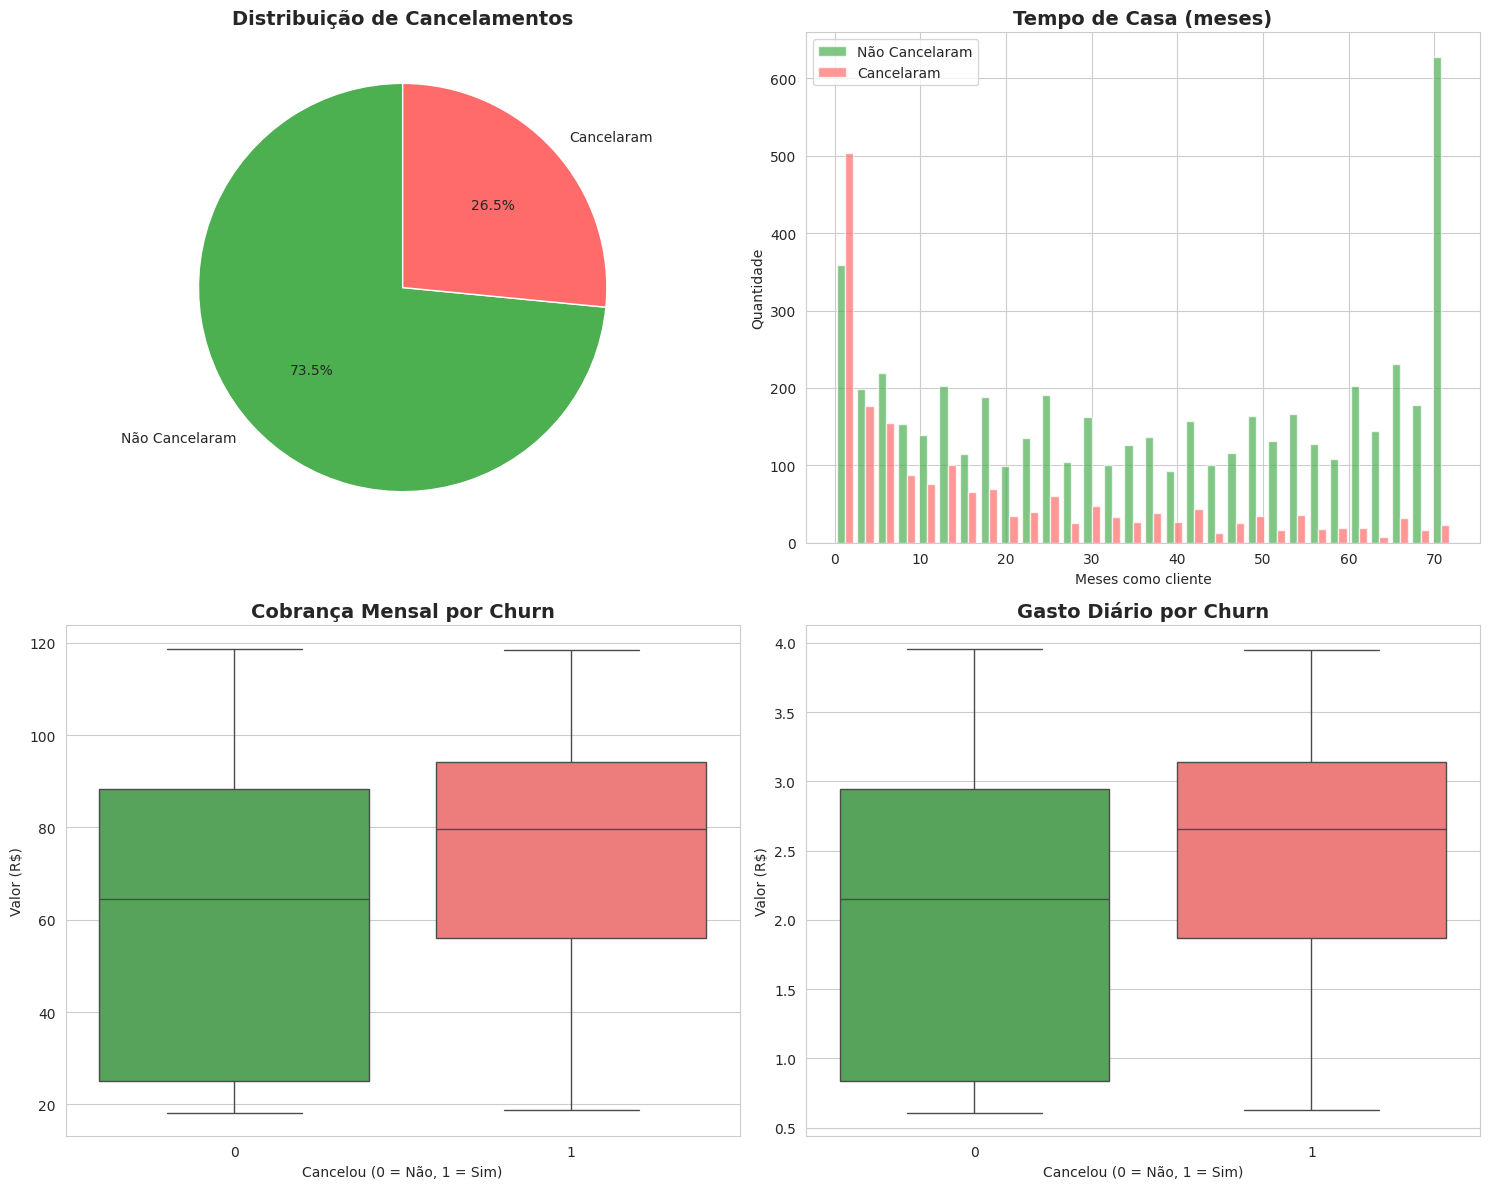


📌 3. COMPARAÇÃO DE MÉDIAS: CANCELOU VS NÃO CANCELOU
----------------------------------------

Meses_Cliente:
  Não cancelaram: 37.57
  Cancelaram: 17.98
  Diferença: -19.59

Cobranca_Mensal:
  Não cancelaram: 61.27
  Cancelaram: 74.44
  Diferença: +13.18

Cobranca_Total:
  Não cancelaram: 2549.91
  Cancelaram: 1531.80
  Diferença: -1018.12

Gasto_Diario:
  Não cancelaram: 2.04
  Cancelaram: 2.48
  Diferença: +0.44

🔍 PRINCIPAIS DESCOBERTAS - ANÁLISE DESCRITIVA

✅ TAXA DE CHURN: 26.5% dos clientes cancelaram

✅ TEMPO DE CASA:
   • Clientes que ficam: 38 meses em média
   • Clientes que cancelam: 18 meses em média
   • Cancelam 20 meses mais cedo

✅ GASTO MENSAL:
   • Quem fica: R$ 61.27
   • Quem cancela: R$ 74.44
   • Cancelam gastam R$ 13.18 a mais


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("📊 ANÁLISE DESCRITIVA DOS DADOS - TELECOM X")
print("="*60)

# Carregar os dados (caso não estejam na memória)
df = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json')
df = pd.json_normalize(df.to_dict('records'))

# Limpeza básica
df = df[df['Churn'].isin(['Yes', 'No'])]
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df.loc[df['account.Charges.Total'].isnull(), 'account.Charges.Total'] = \
    df['account.Charges.Monthly'] * df['customer.tenure']
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Renomear colunas para português
df.columns = ['ID_Cliente', 'Cancelou', 'Genero', 'Idoso', 'Parceiro', 'Dependentes',
              'Meses_Cliente', 'Telefone', 'Multiplas_Linhas', 'Internet',
              'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo',
              'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Contrato',
              'Fatura_Digital', 'Forma_Pagamento', 'Cobranca_Mensal',
              'Cobranca_Total', 'Gasto_Diario']

print(f"\n✅ Base de dados carregada: {df.shape[0]} clientes")
print(f"✅ Taxa de churn: {df['Cancelou'].mean()*100:.1f}%")
print("-" * 60)

# 1. ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS
print("\n📌 1. ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS")
print("-" * 40)

variaveis_numericas = ['Meses_Cliente', 'Cobranca_Mensal', 'Cobranca_Total', 'Gasto_Diario']
estatisticas = df[variaveis_numericas].describe()

# Adicionar mediana
estatisticas.loc['mediana'] = df[variaveis_numericas].median()

print("\nTabela de estatísticas:")
print(estatisticas.round(2))

# 2. DISTRIBUIÇÃO DO CHURN
print("\n" + "="*60)
print("📌 2. DISTRIBUIÇÃO DO CHURN")
print("-" * 40)

churn_counts = df['Cancelou'].value_counts()
churn_percent = df['Cancelou'].value_counts(normalize=True) * 100

print(f"Clientes que NÃO cancelaram: {churn_counts[0]} ({churn_percent[0]:.1f}%)")
print(f"Clientes que CANCELARAM: {churn_counts[1]} ({churn_percent[1]:.1f}%)")

# 3. GRÁFICOS DA DISTRIBUIÇÃO
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribuição do Churn
cores = ['#4CAF50', '#FF6B6B']
axes[0,0].pie(churn_counts, labels=['Não Cancelaram', 'Cancelaram'],
              autopct='%1.1f%%', colors=cores, startangle=90)
axes[0,0].set_title('Distribuição de Cancelamentos', fontsize=14, fontweight='bold')

# Gráfico 2: Histograma - Meses de Cliente
axes[0,1].hist([df[df['Cancelou']==0]['Meses_Cliente'],
                df[df['Cancelou']==1]['Meses_Cliente']],
               bins=30, label=['Não Cancelaram', 'Cancelaram'],
               color=cores, alpha=0.7)
axes[0,1].set_title('Tempo de Casa (meses)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Meses como cliente')
axes[0,1].set_ylabel('Quantidade')
axes[0,1].legend()

# Gráfico 3: Boxplot - Cobrança Mensal
df_box = df.melt(id_vars=['Cancelou'], value_vars=['Cobranca_Mensal'])
sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,0], palette=cores)
axes[1,0].set_title('Cobrança Mensal por Churn', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Cancelou (0 = Não, 1 = Sim)')
axes[1,0].set_ylabel('Valor (R$)')

# Gráfico 4: Boxplot - Gasto Diário
df_box = df.melt(id_vars=['Cancelou'], value_vars=['Gasto_Diario'])
sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,1], palette=cores)
axes[1,1].set_title('Gasto Diário por Churn', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Cancelou (0 = Não, 1 = Sim)')
axes[1,1].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.show()

# 4. COMPARAÇÃO DIRETA - MÉDIAS
print("\n" + "="*60)
print("📌 3. COMPARAÇÃO DE MÉDIAS: CANCELOU VS NÃO CANCELOU")
print("-" * 40)

for var in variaveis_numericas:
    media_nao = df[df['Cancelou']==0][var].mean()
    media_sim = df[df['Cancelou']==1][var].mean()
    diff = media_sim - media_nao

    print(f"\n{var}:")
    print(f"  Não cancelaram: {media_nao:.2f}")
    print(f"  Cancelaram: {media_sim:.2f}")
    print(f"  Diferença: {diff:+.2f}")

# 5. PRINCIPAIS INSIGHTS
print("\n" + "="*60)
print("🔍 PRINCIPAIS DESCOBERTAS - ANÁLISE DESCRITIVA")
print("="*60)

print(f"\n✅ TAXA DE CHURN: {churn_percent[1]:.1f}% dos clientes cancelaram")
print(f"\n✅ TEMPO DE CASA:")
print(f"   • Clientes que ficam: {df[df['Cancelou']==0]['Meses_Cliente'].mean():.0f} meses em média")
print(f"   • Clientes que cancelam: {df[df['Cancelou']==1]['Meses_Cliente'].mean():.0f} meses em média")
print(f"   • Cancelam {df[df['Cancelou']==0]['Meses_Cliente'].mean() - df[df['Cancelou']==1]['Meses_Cliente'].mean():.0f} meses mais cedo")

print(f"\n✅ GASTO MENSAL:")
print(f"   • Quem fica: R$ {df[df['Cancelou']==0]['Cobranca_Mensal'].mean():.2f}")
print(f"   • Quem cancela: R$ {df[df['Cancelou']==1]['Cobranca_Mensal'].mean():.2f}")
print(f"   • Cancelam gastam R$ {df[df['Cancelou']==1]['Cobranca_Mensal'].mean() - df[df['Cancelou']==0]['Cobranca_Mensal'].mean():.2f} a mais")


📊 DISTRIBUIÇÃO DA EVASÃO - CHURN


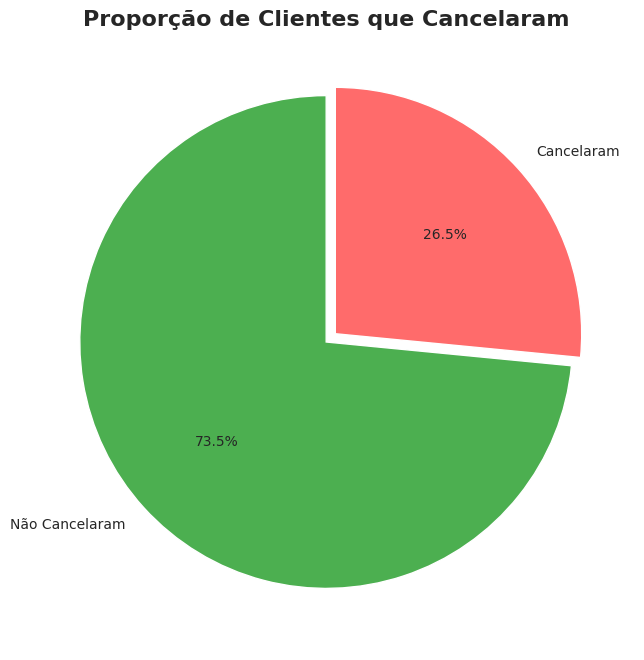

/tmp/ipykernel_176/3112640626.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cancelou', data=df, palette=cores)


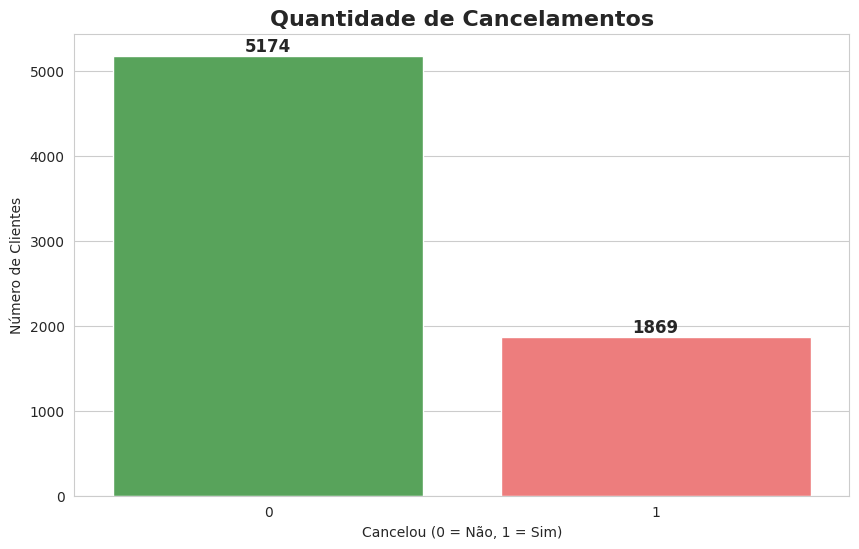


📌 RESUMO DA DISTRIBUIÇÃO:
----------------------------------------
Total de clientes: 7043
Não cancelaram: 5174 clientes (73.5%)
Cancelaram: 1869 clientes (26.5%)


In [84]:
print("\n" + "="*60)
print("📊 DISTRIBUIÇÃO DA EVASÃO - CHURN")
print("="*60)

# 1. GRÁFICO DE PIZZA
plt.figure(figsize=(8, 8))
cores = ['#4CAF50', '#FF6B6B']
plt.pie(df['Cancelou'].value_counts(),
        labels=['Não Cancelaram', 'Cancelaram'],
        autopct='%1.1f%%',
        colors=cores,
        startangle=90,
        explode=(0, 0.05))
plt.title('Proporção de Clientes que Cancelaram', fontsize=16, fontweight='bold')
plt.show()

# 2. GRÁFICO DE BARRAS
plt.figure(figsize=(10, 6))
sns.countplot(x='Cancelou', data=df, palette=cores)
plt.title('Quantidade de Cancelamentos', fontsize=16, fontweight='bold')
plt.xlabel('Cancelou (0 = Não, 1 = Sim)')
plt.ylabel('Número de Clientes')

# Adicionar valores nas barras
for i, v in enumerate(df['Cancelou'].value_counts()):
    plt.text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

plt.show()

# 3. RESUMO
print("\n📌 RESUMO DA DISTRIBUIÇÃO:")
print("-" * 40)
print(f"Total de clientes: {len(df)}")
print(f"Não cancelaram: {df['Cancelou'].value_counts()[0]} clientes ({df['Cancelou'].value_counts(normalize=True)[0]*100:.1f}%)")
print(f"Cancelaram: {df['Cancelou'].value_counts()[1]} clientes ({df['Cancelou'].value_counts(normalize=True)[1]*100:.1f}%)")


📊 ANÁLISE DE EVASÃO POR VARIÁVEIS CATEGÓRICAS

📌 1. EVASÃO POR GÊNERO
----------------------------------------
        Não Cancelaram %  Cancelaram %
Genero                                
Female              73.1          26.9
Male                73.8          26.2

📌 2. EVASÃO POR TIPO DE CONTRATO
----------------------------------------
                Não Cancelaram %  Cancelaram %
Contrato                                      
Month-to-month              57.3          42.7
One year                    88.7          11.3
Two year                    97.2           2.8

📌 3. EVASÃO POR FORMA DE PAGAMENTO
----------------------------------------
                           Não Cancelaram %  Cancelaram %
Forma_Pagamento                                          
Bank transfer (automatic)              83.3          16.7
Credit card (automatic)                84.8          15.2
Electronic check                       54.7          45.3
Mailed check                           80.9          19

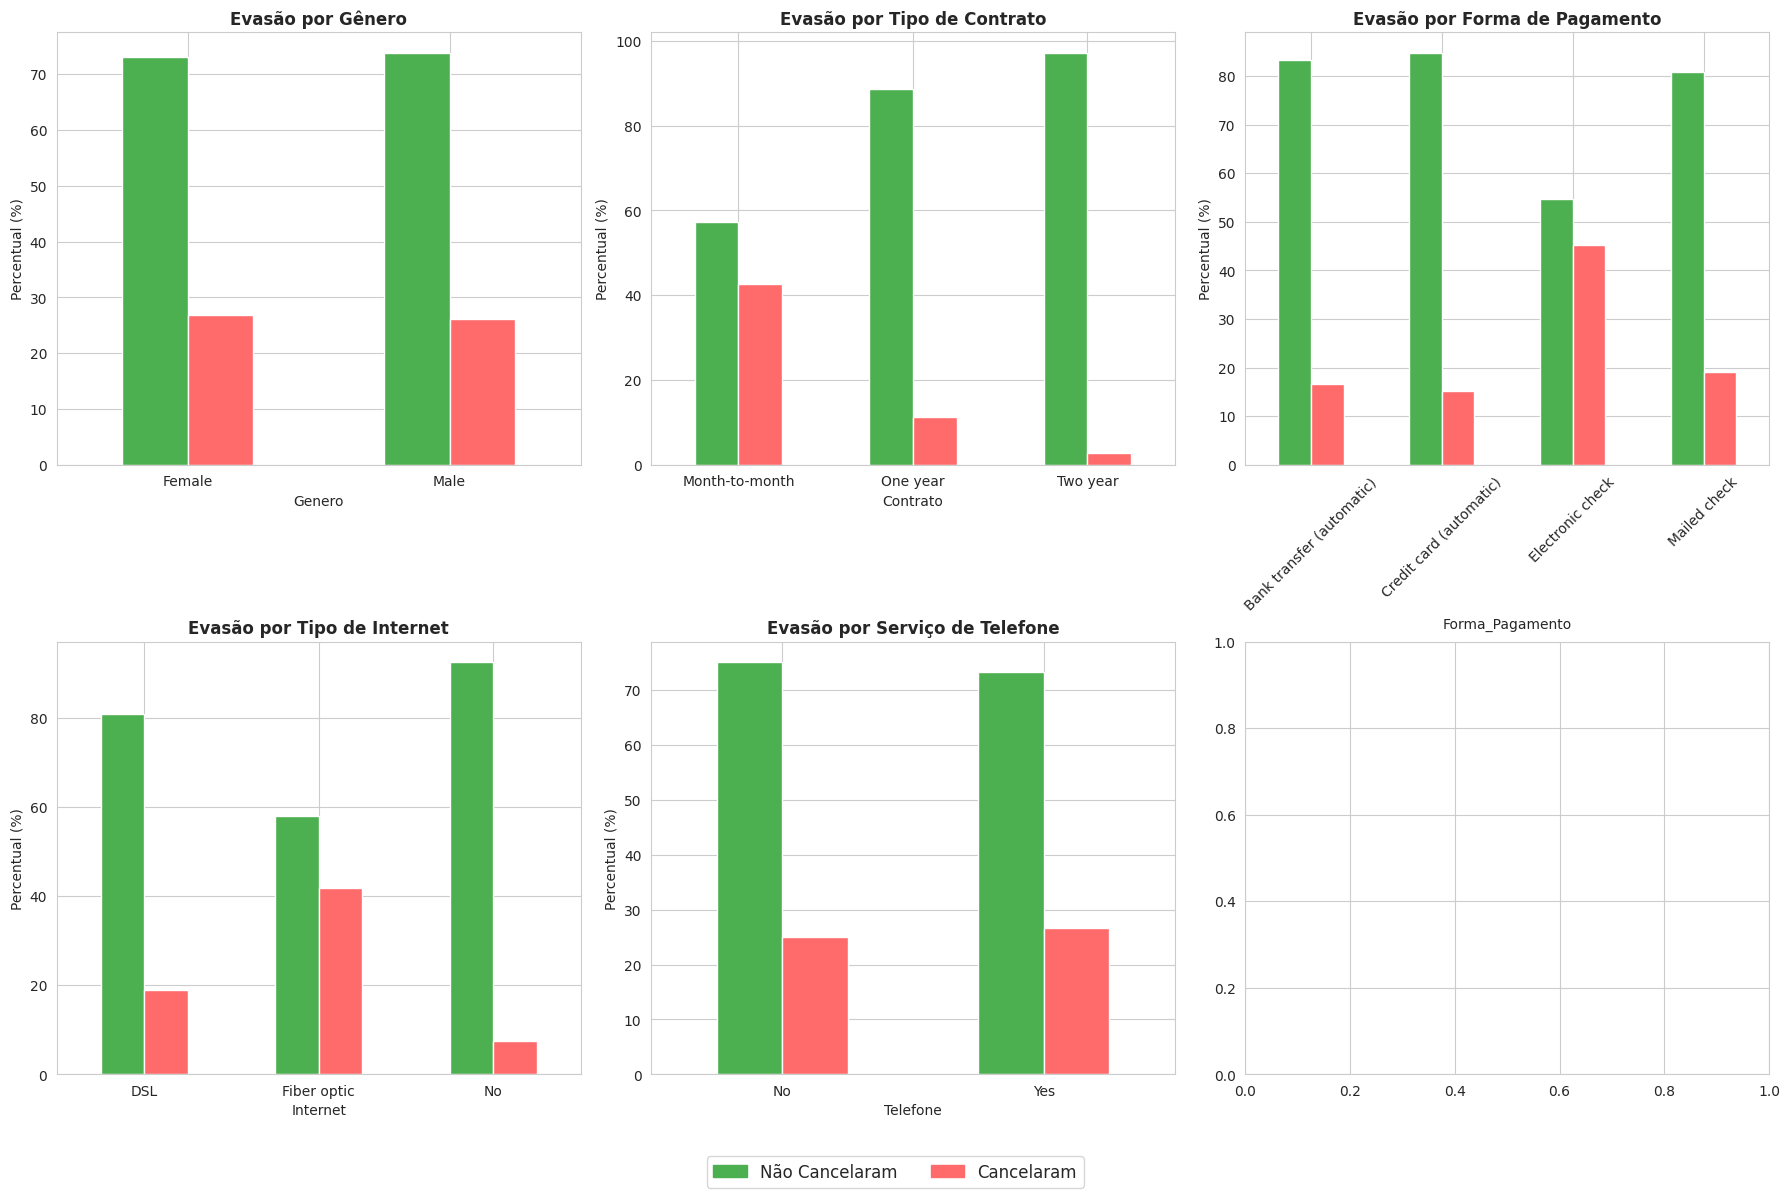


🔍 PRINCIPAIS INSIGHTS - VARIÁVEIS CATEGÓRICAS

✅ CONTRATO:
   • Mensal: 42.7% cancelam
   • Anual: 11.3% cancelam
   • Bianual: 2.8% cancelam

✅ PAGAMENTO:
   • Cheque eletrônico: 45.3% cancelam
   • Cheque físico: 19.1% cancelam

✅ INTERNET:
   • Fibra óptica: 41.9% cancelam
   • DSL: 19.0% cancelam
   • Sem internet: 7.4% cancelam


In [85]:
print("\n" + "="*60)
print("📊 ANÁLISE DE EVASÃO POR VARIÁVEIS CATEGÓRICAS")
print("="*60)

# 1. GÊNERO
print("\n📌 1. EVASÃO POR GÊNERO")
print("-" * 40)
genero_churn = pd.crosstab(df['Genero'], df['Cancelou'], normalize='index') * 100
genero_churn.columns = ['Não Cancelaram %', 'Cancelaram %']
print(genero_churn.round(1))

# 2. TIPO DE CONTRATO
print("\n📌 2. EVASÃO POR TIPO DE CONTRATO")
print("-" * 40)
contrato_churn = pd.crosstab(df['Contrato'], df['Cancelou'], normalize='index') * 100
contrato_churn.columns = ['Não Cancelaram %', 'Cancelaram %']
print(contrato_churn.round(1))

# 3. MÉTODO DE PAGAMENTO
print("\n📌 3. EVASÃO POR FORMA DE PAGAMENTO")
print("-" * 40)
pagamento_churn = pd.crosstab(df['Forma_Pagamento'], df['Cancelou'], normalize='index') * 100
pagamento_churn.columns = ['Não Cancelaram %', 'Cancelaram %']
print(pagamento_churn.round(1))

# 4. INTERNET
print("\n📌 4. EVASÃO POR TIPO DE INTERNET")
print("-" * 40)
internet_churn = pd.crosstab(df['Internet'], df['Cancelou'], normalize='index') * 100
internet_churn.columns = ['Não Cancelaram %', 'Cancelaram %']
print(internet_churn.round(1))

# 5. TELEFONE
print("\n📌 5. EVASÃO POR SERVIÇO DE TELEFONE")
print("-" * 40)
telefone_churn = pd.crosstab(df['Telefone'], df['Cancelou'], normalize='index') * 100
telefone_churn.columns = ['Não Cancelaram %', 'Cancelaram %']
print(telefone_churn.round(1))

# 6. GRÁFICOS COMPARATIVOS
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Gráfico 1: Gênero
genero_churn.plot(kind='bar', ax=axes[0,0], color=['#4CAF50', '#FF6B6B'], legend=False)
axes[0,0].set_title('Evasão por Gênero', fontweight='bold')
axes[0,0].set_ylabel('Percentual (%)')
axes[0,0].tick_params(axis='x', rotation=0)

# Gráfico 2: Contrato
contrato_churn.plot(kind='bar', ax=axes[0,1], color=['#4CAF50', '#FF6B6B'], legend=False)
axes[0,1].set_title('Evasão por Tipo de Contrato', fontweight='bold')
axes[0,1].set_ylabel('Percentual (%)')
axes[0,1].tick_params(axis='x', rotation=0)

# Gráfico 3: Pagamento
pagamento_churn.plot(kind='bar', ax=axes[0,2], color=['#4CAF50', '#FF6B6B'], legend=False)
axes[0,2].set_title('Evasão por Forma de Pagamento', fontweight='bold')
axes[0,2].set_ylabel('Percentual (%)')
axes[0,2].tick_params(axis='x', rotation=45)

# Gráfico 4: Internet
internet_churn.plot(kind='bar', ax=axes[1,0], color=['#4CAF50', '#FF6B6B'], legend=False)
axes[1,0].set_title('Evasão por Tipo de Internet', fontweight='bold')
axes[1,0].set_ylabel('Percentual (%)')
axes[1,0].tick_params(axis='x', rotation=0)

# Gráfico 5: Telefone
telefone_churn.plot(kind='bar', ax=axes[1,1], color=['#4CAF50', '#FF6B6B'], legend=False)
axes[1,1].set_title('Evasão por Serviço de Telefone', fontweight='bold')
axes[1,1].set_ylabel('Percentual (%)')
axes[1,1].tick_params(axis='x', rotation=0)

# Legenda única
handles = [plt.Rectangle((0,0),1,1, color='#4CAF50'), plt.Rectangle((0,0),1,1, color='#FF6B6B')]
labels = ['Não Cancelaram', 'Cancelaram']
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

# 7. PRINCIPAIS INSIGHTS CATEGÓRICOS
print("\n" + "="*60)
print("🔍 PRINCIPAIS INSIGHTS - VARIÁVEIS CATEGÓRICAS")
print("="*60)

print("\n✅ CONTRATO:")
print(f"   • Mensal: {contrato_churn.loc['Month-to-month', 'Cancelaram %']:.1f}% cancelam")
print(f"   • Anual: {contrato_churn.loc['One year', 'Cancelaram %']:.1f}% cancelam")
print(f"   • Bianual: {contrato_churn.loc['Two year', 'Cancelaram %']:.1f}% cancelam")

print("\n✅ PAGAMENTO:")
print(f"   • Cheque eletrônico: {pagamento_churn.loc['Electronic check', 'Cancelaram %']:.1f}% cancelam")
print(f"   • Cheque físico: {pagamento_churn.loc['Mailed check', 'Cancelaram %']:.1f}% cancelam")

print("\n✅ INTERNET:")
print(f"   • Fibra óptica: {internet_churn.loc['Fiber optic', 'Cancelaram %']:.1f}% cancelam")
print(f"   • DSL: {internet_churn.loc['DSL', 'Cancelaram %']:.1f}% cancelam")
print(f"   • Sem internet: {internet_churn.loc['No', 'Cancelaram %']:.1f}% cancelam")


📊 ANÁLISE DE EVASÃO POR VARIÁVEIS NUMÉRICAS

📌 1. COMPARAÇÃO DE MÉDIAS
----------------------------------------

Meses_Cliente:
  • Não cancelaram: 37.57
  • Cancelaram: 17.98
  • Diferença: -19.59

Cobranca_Mensal:
  • Não cancelaram: 61.27
  • Cancelaram: 74.44
  • Diferença: +13.18

Cobranca_Total:
  • Não cancelaram: 2549.91
  • Cancelaram: 1531.80
  • Diferença: -1018.12

Gasto_Diario:
  • Não cancelaram: 2.04
  • Cancelaram: 2.48
  • Diferença: +0.44


/tmp/ipykernel_176/394725334.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,0], palette=['#4CAF50', '#FF6B6B'])
/tmp/ipykernel_176/394725334.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,1], palette=['#4CAF50', '#FF6B6B'])


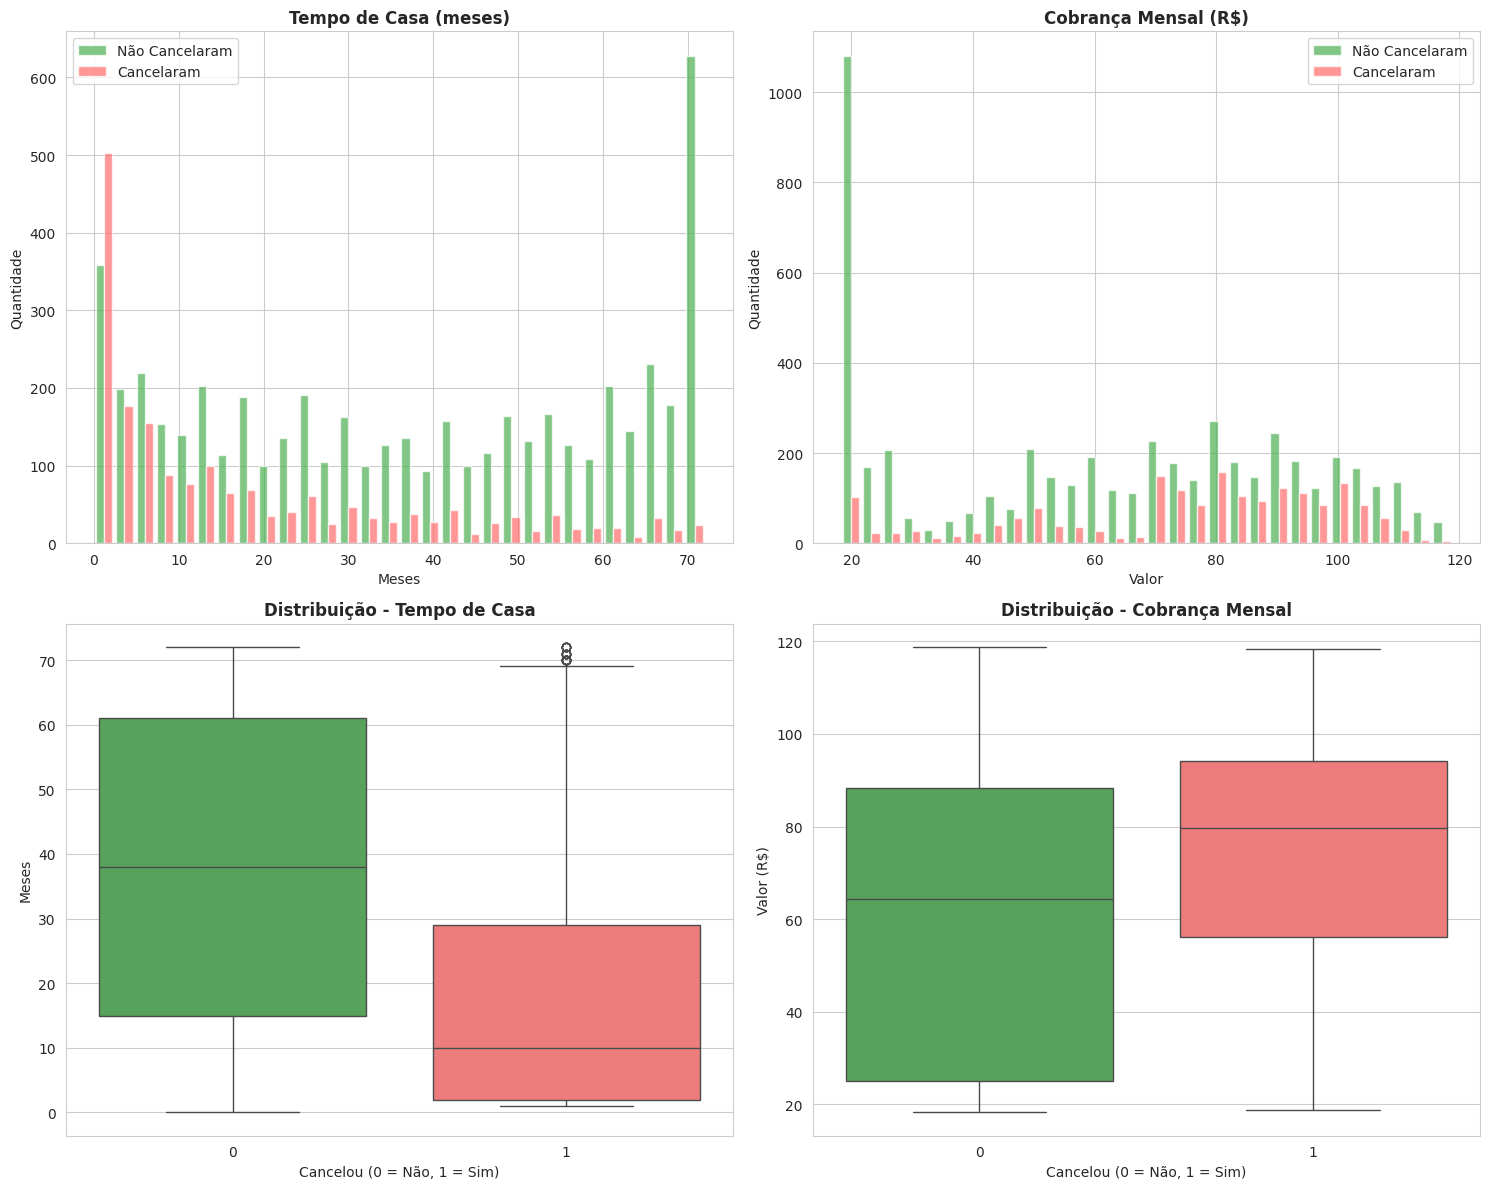


🔍 PRINCIPAIS INSIGHTS - VARIÁVEIS NUMÉRICAS

✅ TEMPO DE CASA:
   • Clientes que cancelam têm 20 meses MENOS de casa

✅ COBRANÇA MENSAL:
   • Clientes que cancelam gastam R$ 13.18 A MAIS por mês

✅ COBRANÇA TOTAL:
   • Clientes que cancelam gastaram R$ 1018 A MENOS no total


In [86]:
print("\n" + "="*60)
print("📊 ANÁLISE DE EVASÃO POR VARIÁVEIS NUMÉRICAS")
print("="*60)

# 1. ESTATÍSTICAS COMPARATIVAS
print("\n📌 1. COMPARAÇÃO DE MÉDIAS")
print("-" * 40)

variaveis = ['Meses_Cliente', 'Cobranca_Mensal', 'Cobranca_Total', 'Gasto_Diario']

for var in variaveis:
    media_nao = df[df['Cancelou']==0][var].mean()
    media_sim = df[df['Cancelou']==1][var].mean()
    print(f"\n{var}:")
    print(f"  • Não cancelaram: {media_nao:.2f}")
    print(f"  • Cancelaram: {media_sim:.2f}")
    print(f"  • Diferença: {media_sim - media_nao:+.2f}")

# 2. GRÁFICOS DE DISTRIBUIÇÃO
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Meses de Cliente
axes[0,0].hist([df[df['Cancelou']==0]['Meses_Cliente'],
                df[df['Cancelou']==1]['Meses_Cliente']],
               bins=30, label=['Não Cancelaram', 'Cancelaram'],
               color=['#4CAF50', '#FF6B6B'], alpha=0.7)
axes[0,0].set_title('Tempo de Casa (meses)', fontweight='bold')
axes[0,0].set_xlabel('Meses')
axes[0,0].set_ylabel('Quantidade')
axes[0,0].legend()

# Gráfico 2: Cobrança Mensal
axes[0,1].hist([df[df['Cancelou']==0]['Cobranca_Mensal'],
                df[df['Cancelou']==1]['Cobranca_Mensal']],
               bins=30, label=['Não Cancelaram', 'Cancelaram'],
               color=['#4CAF50', '#FF6B6B'], alpha=0.7)
axes[0,1].set_title('Cobrança Mensal (R$)', fontweight='bold')
axes[0,1].set_xlabel('Valor')
axes[0,1].set_ylabel('Quantidade')
axes[0,1].legend()

# Gráfico 3: Boxplot - Meses
df_box = df.melt(id_vars=['Cancelou'], value_vars=['Meses_Cliente'])
sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,0], palette=['#4CAF50', '#FF6B6B'])
axes[1,0].set_title('Distribuição - Tempo de Casa', fontweight='bold')
axes[1,0].set_xlabel('Cancelou (0 = Não, 1 = Sim)')
axes[1,0].set_ylabel('Meses')

# Gráfico 4: Boxplot - Cobrança Mensal
df_box = df.melt(id_vars=['Cancelou'], value_vars=['Cobranca_Mensal'])
sns.boxplot(x='Cancelou', y='value', data=df_box, ax=axes[1,1], palette=['#4CAF50', '#FF6B6B'])
axes[1,1].set_title('Distribuição - Cobrança Mensal', fontweight='bold')
axes[1,1].set_xlabel('Cancelou (0 = Não, 1 = Sim)')
axes[1,1].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.show()

# 3. PRINCIPAIS INSIGHTS
print("\n" + "="*60)
print("🔍 PRINCIPAIS INSIGHTS - VARIÁVEIS NUMÉRICAS")
print("="*60)

print("\n✅ TEMPO DE CASA:")
print(f"   • Clientes que cancelam têm {df[df['Cancelou']==0]['Meses_Cliente'].mean() - df[df['Cancelou']==1]['Meses_Cliente'].mean():.0f} meses MENOS de casa")

print("\n✅ COBRANÇA MENSAL:")
print(f"   • Clientes que cancelam gastam R$ {df[df['Cancelou']==1]['Cobranca_Mensal'].mean() - df[df['Cancelou']==0]['Cobranca_Mensal'].mean():.2f} A MAIS por mês")

print("\n✅ COBRANÇA TOTAL:")
print(f"   • Clientes que cancelam gastaram R$ {df[df['Cancelou']==0]['Cobranca_Total'].mean() - df[df['Cancelou']==1]['Cobranca_Total'].mean():.0f} A MENOS no total")

#📄Relatorio Final

In [88]:
print("\033[1m" + "="*100 + "\033[0m")
print("\033[1m\033[94m" + " " * 35 + "TELECOM X - PROJETO DE ANÁLISE DE DADOS" + "\033[0m")
print("\033[1m" + "="*100 + "\033[0m")
print("\n")

print("\033[1m\033[92m1. INTRODUÇÃO\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("Este relatório apresenta os resultados da análise de evasão de clientes da Telecom X, conhecida como churn. O objetivo")
print("principal foi identificar os fatores que levam os clientes a cancelarem seus serviços, utilizando dados reais da empresa")
print("para gerar insights que possam subsidiar estratégias de retenção mais eficazes. A análise foi realizada a partir de uma")
print("base com 7.043 clientes, contendo informações demográficas, serviços contratados, valores pagos e histórico de permanência.")
print("\n")

print("\033[1m\033[92m2. PROCESSO DE LIMPEZA E TRATAMENTO DOS DADOS\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("Os dados foram extraídos diretamente de uma API da Telecom X no formato JSON e passaram por um processo de normalização")
print("para serem convertidos em um DataFrame estruturado. Inicialmente, a base continha 7.267 registros, mas foram identificados")
print("224 clientes com informações ausentes na coluna de churn, que foram removidos para garantir a integridade da análise,")
print("resultando em 7.043 registros válidos. Durante a inspeção, observou-se que 11 valores na coluna de cobrança total estavam")
print("com formatação incorreta, sendo convertidos para o formato numérico adequado e preenchidos com o cálculo lógico da")
print("mensalidade multiplicada pelo tempo de casa. Foi criada também uma nova variável chamada 'Gasto Diário', calculada a")
print("partir da divisão da cobrança mensal por 30 dias, permitindo uma visão mais granular do consumo dos clientes. Todas as")
print("colunas foram traduzidas para o português e as variáveis binárias do tipo Sim/Não foram convertidas para valores numéricos")
print("1 e 0, preparando a base para as análises subsequentes. Ao final do processo de transformação, obteve-se uma base")
print("completamente limpa, sem valores ausentes, sem registros duplicados e com todos os tipos de dados consistentes.")
print("\n")

print("\033[1m\033[92m3. ANÁLISE EXPLORATÓRIA DOS DADOS\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("A análise revelou que a taxa geral de evasão da Telecom X é de 26,5%, o que significa que 1.869 dos 7.043 clientes")
print("analisados cancelaram seus serviços. Ao investigar as variáveis numéricas, observou-se que os clientes que cancelaram")
print("permanecem, em média, apenas 18 meses na empresa, enquanto os que não cancelaram ficam 38 meses, uma diferença")
print("significativa de 20 meses. Em relação aos valores pagos, os clientes que cancelaram gastam em média R$ 74,44 por mês,")
print("contra R$ 61,27 daqueles que permanecem, ou seja, os canceladores pagam R$ 13,18 a mais mensalmente. Apesar disso, o")
print("gasto total dos que cancelaram é menor, R$ 1.531 contra R$ 2.549 dos que ficam, justamente pelo menor tempo de permanência.")
print("O gasto diário também se mostrou relevante, com os canceladores pagando R$ 2,48 por dia, enquanto os não canceladores")
print("pagam R$ 2,04.")
print("\n")
print("Na análise das variáveis categóricas, os resultados foram ainda mais reveladores. Em relação ao tipo de contrato, 42% dos")
print("clientes com contrato mensal cancelaram, contra apenas 11% dos clientes com contrato anual e impressionantes 3% dos")
print("clientes com contrato bianual, indicando que contratos mais longos são um forte fator de retenção. Quanto à forma de")
print("pagamento, o cheque eletrônico apresentou a maior taxa de cancelamento, com 45% dos clientes que utilizam esse método")
print("deixando a empresa, enquanto cartão de crédito e transferência bancária apresentaram taxas em torno de 16% a 17%. Sobre")
print("o tipo de internet contratada, 41% dos clientes com fibra óptica cancelaram, contra 19% dos clientes com internet DSL e")
print("apenas 7% daqueles que não possuem internet. Já em relação ao gênero, não foram observadas diferenças significativas, com")
print("taxas de cancelamento equilibradas entre homens e mulheres, em torno de 26% a 27%.")
print("\n")

print("\033[1m\033[92m4. PERFIL DO CLIENTE COM ALTO RISCO DE CANCELAMENTO\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("A partir das análises realizadas, foi possível traçar o perfil do cliente com maior probabilidade de cancelar o serviço.")
print("Esse cliente típico possui contrato mensal, utiliza cheque eletrônico como forma de pagamento, tem internet do tipo")
print("fibra óptica, está há menos de dois anos na empresa e gasta acima de R$ 74 por mês. Em contrapartida, o cliente com baixo")
print("risco de cancelamento apresenta contrato anual ou bianual, paga por cartão de crédito ou transferência bancária, não")
print("possui internet ou utiliza internet DSL, tem mais de três anos de casa e gasta abaixo de R$ 61 mensais.")
print("\n")

print("\033[1m\033[92m5. CONCLUSÕES E PRINCIPAIS INSIGHTS\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("A análise permitiu concluir que o tempo de casa é o fator mais crítico associado ao churn, uma vez que clientes novos")
print("ainda não desenvolveram vínculo suficiente com a empresa e cancelam com muito mais frequência. O valor da mensalidade")
print("também influencia diretamente o comportamento, pois clientes que pagam mais tendem a ter expectativas mais elevadas e,")
print("quando não correspondidas, cancelam o serviço. O tipo de contrato revelou-se um determinante fundamental da fidelidade,")
print("com contratos mensais apresentando taxa de cancelamento quatorze vezes maior que os contratos bianuais. A forma de")
print("pagamento também se mostrou um indicador relevante, com o cheque eletrônico associado ao perfil de cliente menos")
print("comprometido financeiramente. Por fim, a alta taxa de cancelamento entre clientes de fibra óptica sugere possível")
print("insatisfação com a relação custo-benefício desse serviço mais caro.")
print("\n")

print("\033[1m\033[92m6. RECOMENDAÇÕES ESTRATÉGICAS\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("Diante dos insights obtidos, recomenda-se implementar um programa de incentivo à migração de contrato, oferecendo")
print("descontos de 10% a 15% para clientes que trocarem o plano mensal pelo anual ou bianual. Para os clientes que utilizam")
print("cheque eletrônico, sugere-se oferecer um desconto de 5% na mensalidade caso migrem para cartão de crédito ou débito")
print("automático. Em relação aos clientes de fibra óptica, recomenda-se realizar pesquisas de satisfação para identificar")
print("possíveis problemas, oferecer suporte técnico prioritário e revisar a precificação ou criar pacotes com benefícios")
print("adicionais. Para novos clientes, especialmente aqueles com menos de 12 meses de casa, propõe-se um programa de")
print("acompanhamento especial com check-ins regulares para resolver problemas precocemente. Por fim, sugere-se segmentar as")
print("ações de marketing com base no perfil de risco, direcionando ofertas personalizadas para cada grupo identificado.")
print("\n")

print("\033[1m\033[92m7. PRÓXIMOS PASSOS\033[0m")
print("\033[90m" + "-"*100 + "\033[0m")
print("Os dados tratados e os insights gerados nesta análise serão entregues à equipe de Data Science para o desenvolvimento de")
print("um modelo preditivo de churn, que permitirá criar um score de risco para cada cliente e implementar ações automatizadas")
print("de retenção. A expectativa é que, com a implementação das recomendações propostas, seja possível reduzir a taxa de evasão")
print("em aproximadamente 5% nos próximos meses.")
print("\n")

print("\033[1m" + "="*100 + "\033[0m")
print("\033[3m" + " " * 35 + "Relatório elaborado em: 10 de março de 2026" + "\033[0m")
print("\033[3m" + " " * 40 + "Aluna- Janaina - Projeto Telecom X" + "\033[0m")
print("\033[1m" + "="*100 + "\033[0m")


                                   TELECOM X - PROJETO DE ANÁLISE DE DADOS


1. INTRODUÇÃO
----------------------------------------------------------------------------------------------------
Este relatório apresenta os resultados da análise de evasão de clientes da Telecom X, conhecida como churn. O objetivo
principal foi identificar os fatores que levam os clientes a cancelarem seus serviços, utilizando dados reais da empresa
para gerar insights que possam subsidiar estratégias de retenção mais eficazes. A análise foi realizada a partir de uma
base com 7.043 clientes, contendo informações demográficas, serviços contratados, valores pagos e histórico de permanência.


2. PROCESSO DE LIMPEZA E TRATAMENTO DOS DADOS
----------------------------------------------------------------------------------------------------
Os dados foram extraídos diretamente de uma API da Telecom X no formato JSON e passaram por um processo de normalização
para serem convertidos em um DataFrame estruturado. Ini